In [1]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), 
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
query = """
SELECT *
FROM features.department_features
"""

department_df = pd.read_sql(query, engine)

department_df.shape

(21, 5)

In [4]:
department_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   department        21 non-null     object 
 1   purchase_count    21 non-null     int64  
 2   unique_customers  21 non-null     int64  
 3   unique_products   21 non-null     int64  
 4   reorder_rate      21 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 972.0+ bytes


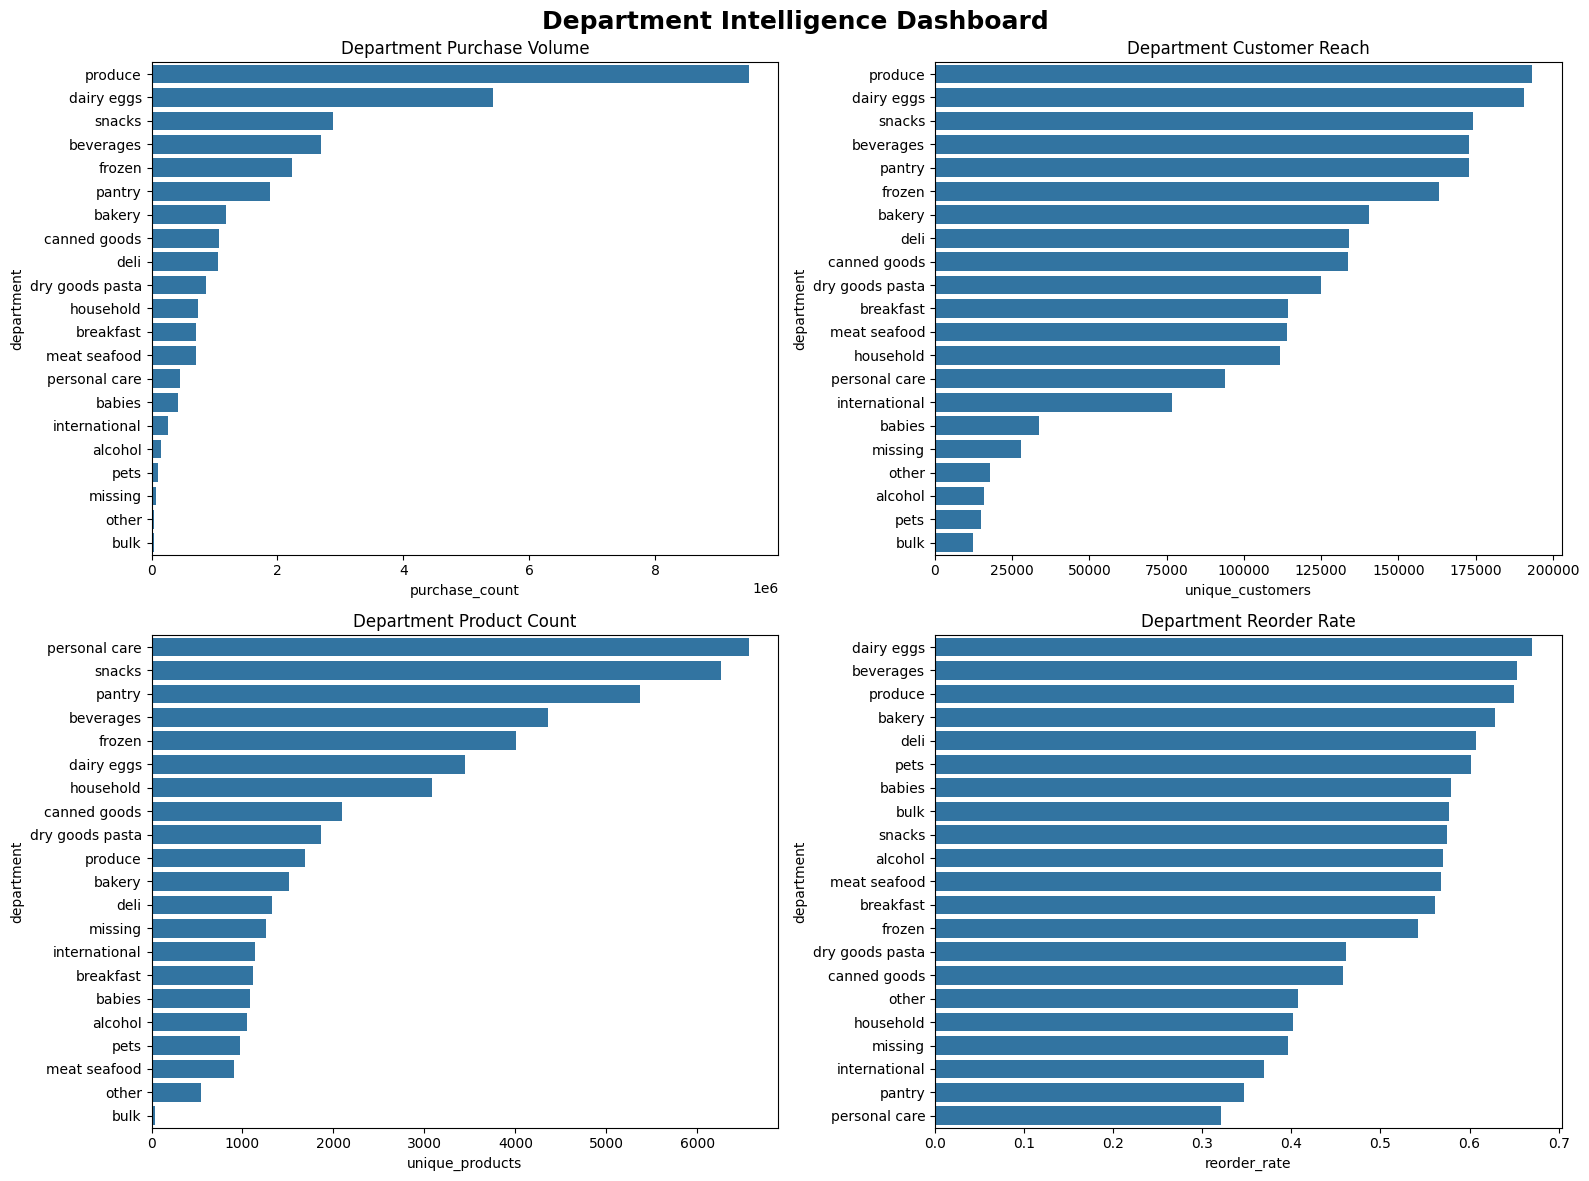

In [5]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

axes = axes.flatten()

# --------------------------------------------------
# 1. Purchase Count
# --------------------------------------------------

dept_purchase = department_df.sort_values(
    "purchase_count",
    ascending=False
)

sns.barplot(
    data=dept_purchase,
    x="purchase_count",
    y="department",
    ax=axes[0]
)

axes[0].set_title(
    "Department Purchase Volume"
)

# --------------------------------------------------
# 2. Customer Reach
# --------------------------------------------------

dept_customers = department_df.sort_values(
    "unique_customers",
    ascending=False
)

sns.barplot(
    data=dept_customers,
    x="unique_customers",
    y="department",
    ax=axes[1]
)

axes[1].set_title(
    "Department Customer Reach"
)

# --------------------------------------------------
# 3. Product Catalog Size
# --------------------------------------------------

dept_products = department_df.sort_values(
    "unique_products",
    ascending=False
)

sns.barplot(
    data=dept_products,
    x="unique_products",
    y="department",
    ax=axes[2]
)

axes[2].set_title(
    "Department Product Count"
)

# --------------------------------------------------
# 4. Reorder Rate
# --------------------------------------------------

dept_reorders = department_df.sort_values(
    "reorder_rate",
    ascending=False
)

sns.barplot(
    data=dept_reorders,
    x="reorder_rate",
    y="department",
    ax=axes[3]
)

axes[3].set_title(
    "Department Reorder Rate"
)

plt.suptitle(
    "Department Intelligence Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Department Intelligence Analysis

The Department Intelligence Dashboard provides a category-level view of purchasing behavior across 21 product departments. It highlights department popularity, customer reach, catalog size, and customer loyalty.

---

## 1. Department Purchase Volume

Purchase volume is highly concentrated among a small number of departments.

### Key Insights

- Produce dominates all departments by a significant margin.
- Dairy & Eggs is the second-largest department.
- Snacks, Beverages, Frozen, and Pantry form the next tier of high-volume departments.
- Several departments contribute only a small fraction of total purchases.

### Business Implications

- Produce is the primary demand driver of the platform.
- Inventory availability within Produce and Dairy & Eggs is critical for customer satisfaction.
- High-volume departments should receive priority in forecasting and replenishment systems.

---

## 2. Department Customer Reach

Customer reach measures how many unique customers purchase from each department.

### Key Insights

- Produce reaches nearly the entire customer base.
- Dairy & Eggs, Snacks, Beverages, and Pantry also demonstrate broad customer penetration.
- Specialty departments such as Alcohol, Pets, and Bulk have significantly smaller customer reach.

### Business Implications

- High-reach departments represent universal shopping categories.
- Recommendations built around these departments are likely to be relevant to a large portion of customers.
- Niche departments may require targeted marketing strategies.

---

## 3. Department Product Count

Product count measures catalog breadth within each department.

### Key Insights

- Personal Care contains the largest number of products.
- Snacks and Pantry also maintain extensive product catalogs.
- Produce generates the highest purchase volume despite having a relatively smaller catalog compared to some departments.

### Business Interpretation

Two distinct department types emerge:

#### High-Volume Departments

- Produce
- Dairy & Eggs
- Snacks

These departments generate substantial demand despite moderate catalog sizes.

#### High-Catalog Departments

- Personal Care
- Pantry
- Beverages

These departments offer greater product diversity and customer choice.

### Business Implications

- Product variety does not necessarily translate to higher purchase volume.
- Some departments succeed through a small number of highly popular products.

---

## 4. Department Reorder Rate

Reorder rate measures customer loyalty at the department level.

### Key Insights

Top loyalty departments include:

- Dairy & Eggs
- Beverages
- Produce
- Bakery
- Deli

Lower loyalty departments include:

- Personal Care
- Pantry
- International
- Household

### Business Interpretation

Departments containing frequently consumed products tend to exhibit higher reorder rates.

Examples include:

- Milk
- Eggs
- Fresh produce
- Beverages

These products naturally require regular replenishment.

### Business Implications

- High-reorder departments are ideal candidates for subscription and replenishment services.
- Demand forecasting is likely to be more reliable in these departments.
- Recommendation systems should prioritize replenishment reminders for products within these categories.

---

# Overall Findings

The department analysis reveals three major business patterns:

### 1. Produce Dominates Platform Activity

Produce leads both purchase volume and customer reach, making it the most strategically important department.

### 2. Catalog Size and Demand Are Not Strongly Related

Departments such as Personal Care contain large product catalogs but generate lower purchase volumes than Produce or Dairy & Eggs.

### 3. Loyalty Is Strongest in Consumable Categories

Departments containing regularly consumed products demonstrate the highest reorder rates and customer retention.

---

# Conclusion

Department-level analysis reveals that customer purchasing behavior is heavily concentrated around essential grocery categories. Produce, Dairy & Eggs, Snacks, and Beverages form the core of platform activity, while high-loyalty departments demonstrate strong replenishment behavior.

These insights support:

- Inventory optimization
- Demand forecasting
- Category management
- Replenishment recommendations
- Personalized marketing strategies

The department intelligence layer provides a high-level view of customer demand and serves as a bridge between product-level analytics and broader business decision-making.